In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

In [2]:
clf_model_path =  "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_classification_model.pkl"
reg_model_path = "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_regression_model.pkl"
all_feature_csv = "../media/Inference/full_dataset_Polypgen_20250421_222611/model_training_data.csv"
test_feature_csv = "../media/Inference/test_dataset_Polypgen_20250422_114853/model_training_data.csv"

In [3]:
df = pd.read_csv(all_feature_csv)
df.head()

,X,y,y_tmp,mean_future_iou_c,mean_future_iou_u
0,"[0.7922935550783264, -3.984292507171631, 4.252...",0,-0.008446,0.622668,0.631113
1,"[0.8970150011828646, -3.8044822216033936, 4.37...",0,-0.005549,0.575036,0.580584
2,"[0.9517839703412694, -3.81430721282959, 4.4264...",0,0.051758,0.551534,0.499775
3,"[0.9403030066834425, -4.428088188171387, 5.013...",0,0.014919,0.440848,0.425929
4,"[0.9607740533662056, -4.056418418884277, 5.292...",0,0.395548,0.735721,0.340173


In [4]:
df["X"]

0       [0.7922935550783264, -3.984292507171631, 4.252...
1       [0.8970150011828646, -3.8044822216033936, 4.37...
2       [0.9517839703412694, -3.81430721282959, 4.4264...
3       [0.9403030066834425, -4.428088188171387, 5.013...
4       [0.9607740533662056, -4.056418418884277, 5.292...
                              ...                        
1379    [0.1111412411654255, -11.259041786193848, 3.62...
1380                [0.0, -1024.0, 0.0, 0.0, -0.21582031]
1381                  [0.0, -1024.0, 0.0, 0.0, -1.046875]
1382                [0.0, -1024.0, 0.0, 0.0, -0.98828125]
1383                [0.0, -1024.0, 0.0, 0.0, -0.55078125]
Name: X, Length: 1384, dtype: object

In [5]:
df["y"].value_counts()

y
0    1245
1     139
Name: count, dtype: int64

In [ ]:
import ast
df['X'] = df['X'].apply(ast.literal_eval)
X_expanded = pd.DataFrame(df['X'].tolist(), index=df.index)
X_expanded.columns = [f'X_{i}' for i in range(X_expanded.shape[1])]
# Concatenate the new columns with the original DataFrame
df = pd.concat([df, X_expanded], axis=1)
df.drop(columns=['X'], inplace=True)
df.drop(columns=['X'], inplace=True)
# Extract the dataframe consisting of X_0, X_1, X_2, X_3, and X_4
X_df = df[['X_0', 'X_1', 'X_2', 'X_3', 'X_4']]
X_df

,X_0,X_1,X_2,X_3,X_4
0,0.792294,-3.984293,4.252599,104284.0,8.500000
1,0.897015,-3.804482,4.377153,112165.0,7.625000
2,0.951784,-3.814307,4.426447,107990.0,7.250000
3,0.940303,-4.428088,5.013247,97682.0,7.718750
4,0.960774,-4.056418,5.292379,104888.0,7.062500
...,...,...,...,...,...
1379,0.111141,-11.259042,3.627240,16973.0,0.476562
1380,0.000000,-1024.000000,0.000000,0.0,-0.215820
1381,0.000000,-1024.000000,0.000000,0.0,-1.046875
1382,0.000000,-1024.000000,0.000000,0.0,-0.988281


In [7]:
# Standardize X_df values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Convert df['y'] to classification labels (assuming binary classification)
y_class = np.where(df['y'] > 0, 1, 0)

# Train-test split with a fixed split (using a fixed random state)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# Train a logistic regression model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict on the test set and get probabilities
y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")




Accuracy: 0.9133574007220217


In [8]:
pd.Series(y_pred).value_counts()

0    269
1      8
Name: count, dtype: int64

In [9]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1])

In [10]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [11]:
y_pred_proba[:, 1]

array([3.87080426e-02, 8.16718425e-02, 4.37348121e-02, 2.46353189e-02,
       8.89874492e-02, 6.55142316e-02, 1.24647096e-01, 1.10401313e-01,
       5.35498596e-02, 4.84507805e-02, 7.71749946e-02, 1.41609820e-01,
       5.24248019e-02, 3.96365798e-02, 6.44612248e-02, 6.57168140e-02,
       3.10851589e-01, 2.99509466e-02, 4.15413112e-01, 5.22121895e-02,
       7.98613684e-03, 8.26037755e-02, 5.11915981e-01, 1.97974231e-02,
       4.05087004e-01, 7.26497878e-01, 8.90089040e-03, 8.31813105e-02,
       2.22303542e-03, 2.38985033e-02, 1.42416616e-01, 9.61451505e-02,
       8.02459901e-02, 6.12750045e-02, 8.63565541e-02, 1.17663954e-03,
       1.53691901e-02, 3.34135048e-02, 1.18294240e-01, 1.57365176e-02,
       6.42969499e-03, 8.22117348e-02, 2.38561121e-01, 5.40803849e-02,
       2.94684772e-02, 6.81669188e-01, 5.41798043e-02, 2.61347149e-02,
       6.02123729e-02, 8.38736944e-03, 2.72077623e-02, 4.73087267e-02,
       1.11804796e-01, 1.72431244e-02, 1.47325869e-01, 5.61419709e-02,
      

In [12]:

results_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba[:, 1]
})

# Write the DataFrame to a CSV file
results_df.to_csv('results.csv', index=False)

# Display the first few rows of the results DataFrame to verify
results_df.head()

,y_test,y_pred,y_pred_proba
0,0,0,0.038708
1,0,0,0.081672
2,0,0,0.043735
3,0,0,0.024635
4,0,0,0.088987


In [13]:
len(y_test),len(y_pred),len(y_pred_proba[:, 1])

(277, 277, 277)

In [14]:
len(y_test)

277

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Get predictions
y_pred_reg = reg.predict(X_test)

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)



MSE: 0.07684361276194121
R2 Score: 0.1543124550185042


In [17]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.41392087936401367


In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))  

0.4812884968445209


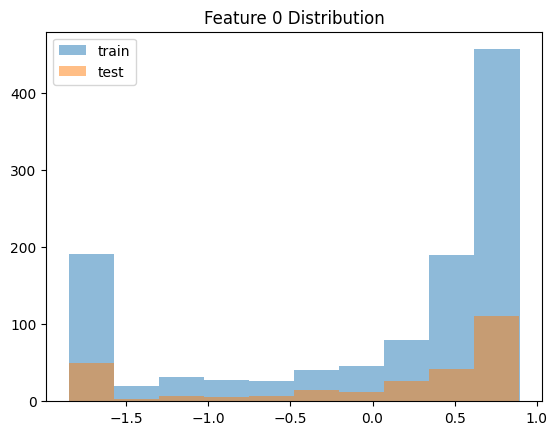

In [21]:
import matplotlib.pyplot as plt
plt.hist(X_train[:, 0], alpha=0.5, label='train')
plt.hist(X_test[:, 0], alpha=0.5, label='test')
plt.legend()
plt.title("Feature 0 Distribution")
plt.show()

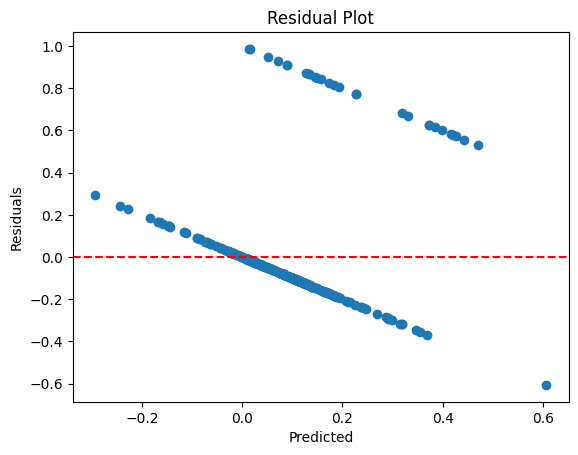

In [22]:
residuals = y_test - y_pred_reg
plt.scatter(y_pred_reg, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [23]:
print("Correlation:", np.corrcoef(y_test, y_pred_reg)[0, 1])

Correlation: 0.3958264169969136


In [24]:
y_pred_flipped = -y_pred
r2 = r2_score(y_test, y_pred_flipped)
print("Flipped R²:", r2)

Flipped R²: -0.907056798623064


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train regression model
reg = LinearRegression()
reg.fit(X_train['X_4'], y_train)

# Get predictions
y_pred_reg = reg.predict(X_test['X_4'])

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [17]:
X_train

array([[-1.85009815, -2.57786751, -1.95917512, -0.84464252, -2.28478378],
       [ 0.6765393 ,  0.37996399,  1.07108571,  0.37312529,  0.909194  ],
       [-1.85009815,  0.38512067, -0.0153127 , -0.42514485, -0.55930153],
       ...,
       [-1.03070445,  0.39796864, -0.88756107, -0.7241532 , -1.47596398],
       [ 0.84113299,  0.41247852,  1.90930341,  2.34833098,  0.2190011 ],
       [-0.05074874,  0.38518731,  0.04284982, -0.06237873,  0.93856391]])